In [8]:
import pandas as pd
import numpy as np
import re
import networkx as nx
import matplotlib.pyplot as plt

# (Opcional pero recomendado para layers GIS)
import geopandas as gpd
from shapely.geometry import Point, LineString


LINE_COLS = {
    "Red": "RED",
    "Blue": "BLUE",
    "Green": "G",
    "Brown": "BRN",
    "Purple": "P",
    "Yellow": "Y",
    "Pink": "Pnk",
    "Orange": "O",
}

LINE_COLORS = {
    "Red": "red",
    "Blue": "dodgerblue",
    "Green": "green",
    "Brown": "saddlebrown",
    "Purple": "purple",
    "Yellow": "gold",
    "Pink": "hotpink",
    "Orange": "orange",
}


def _parse_location_to_latlon(val):
    """
    Location viene como string tipo: '    (41.857908, -87.669147)'
    retorna (lat, lon) floats o (nan, nan)
    """
    m = re.search(r"\(\s*([-\d\.]+)\s*,\s*([-\d\.]+)\s*\)", str(val))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))


def prepare_station_level_df(stops_df: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte el DF de stops (STOP_ID por dirección) a station-level (MAP_ID).
    - parsea Location -> LATITUDE, LONGITUDE
    - normaliza columnas booleanas de líneas
    - agrupa por MAP_ID conservando coordenadas y flags de líneas
    """
    df = stops_df.copy()

    # Parse location
    latlon = df["Location"].apply(_parse_location_to_latlon)
    df["LATITUDE"] = latlon.apply(lambda x: x[0])
    df["LONGITUDE"] = latlon.apply(lambda x: x[1])

    # Normalizar columnas de líneas a bool (por si vienen como 'true'/'false')
    for col in LINE_COLS.values():
        if col not in df.columns:
            raise KeyError(f"Falta la columna de línea: {col}")

        if df[col].dtype == object:
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": True, "false": False})
            )

        # Si quedaron NaNs, conviértelos a False
        df[col] = df[col].fillna(False).astype(bool)

    # Colapsar a station-level usando MAP_ID
    # (tomamos primera coord/nombre; y OR lógico en líneas)
    agg = {
        "STATION_NAME": "first",
        "STATION_DESCRIPTIVE_NAME": "first",
        "LATITUDE": "first",
        "LONGITUDE": "first",
    }
    for col in LINE_COLS.values():
        agg[col] = "max"

    stations = (
        df.groupby("MAP_ID", as_index=False)
          .agg(agg)
          .dropna(subset=["LATITUDE", "LONGITUDE"])
    )

    # Asegura tipo consistente
    stations["MAP_ID"] = stations["MAP_ID"].astype(int)

    return stations


def haversine_meters(lon1, lat1, lon2, lat2):
    """
    Distancia Haversine (aprox) en metros. Inputs en grados.
    """
    R = 6371000.0
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))


def create_connected_graph_from_cta(stations_df: pd.DataFrame, line_name: str) -> nx.Graph:
    """
    Crea grafo completo de estaciones en una línea (filtrando por columna bool de la línea).
    Nodos: MAP_ID
    Pos: (lon, lat)
    Weight: distancia haversine (m)
    """
    if line_name not in LINE_COLS:
        raise ValueError(f"line_name inválido: {line_name}. Usa: {list(LINE_COLS.keys())}")

    line_col = LINE_COLS[line_name]
    sub = stations_df[stations_df[line_col]].copy()

    G = nx.Graph(line=line_name)

    # Nodos
    for _, r in sub.iterrows():
        G.add_node(
            int(r["MAP_ID"]),
            pos=(float(r["LONGITUDE"]), float(r["LATITUDE"])),
            station_name=r["STATION_NAME"],
            station_desc=r["STATION_DESCRIPTIVE_NAME"],
        )

    # Aristas completas (O(n^2)) + peso geodésico
    nodes = list(G.nodes(data=True))
    for i in range(len(nodes)):
        u, du = nodes[i]
        lon1, lat1 = du["pos"]
        for j in range(i + 1, len(nodes)):
            v, dv = nodes[j]
            lon2, lat2 = dv["pos"]
            w = float(haversine_meters(lon1, lat1, lon2, lat2))
            G.add_edge(u, v, weight=w)

    return G


def minimum_spanning_tree(G: nx.Graph) -> nx.Graph:
    return nx.minimum_spanning_tree(G, weight="weight")


def modify_connection(G, remove_edge=None, add_edge=None, weight=None):
    if remove_edge:
        if G.has_edge(*remove_edge):
            G.remove_edge(*remove_edge)
            print(f"Removed edge: {remove_edge}")
        else:
            print(f"Edge {remove_edge} does not exist.")

    if add_edge:
        if weight is None:
            pos = nx.get_node_attributes(G, "pos")
            lon1, lat1 = pos[add_edge[0]]
            lon2, lat2 = pos[add_edge[1]]
            weight = float(haversine_meters(lon1, lat1, lon2, lat2))
        G.add_edge(add_edge[0], add_edge[1], weight=float(weight))
        print(f"Added edge: {add_edge} with weight {weight:.2f} m")

    return G


def plot_graph(G, line_name: str):
    pos = nx.get_node_attributes(G, "pos")
    c = LINE_COLORS.get(line_name, "gray")

    plt.figure(figsize=(10, 10))
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.5)
    nx.draw_networkx_nodes(G, pos, node_color=c, node_size=60, alpha=0.65)
    # si quieres labels, descomenta (pero suele saturar)
    # nx.draw_networkx_labels(G, pos, font_size=7)

    plt.title(f"CTA L — {line_name} (MST backbone)")
    plt.axis("equal")
    plt.show()


def graph_to_geodataframes(G: nx.Graph):
    """
    Convierte grafo (con 'pos') a GeoDataFrames:
    - nodes_gdf: puntos
    - edges_gdf: LineStrings
    """
    pos = nx.get_node_attributes(G, "pos")

    node_rows = []
    for n, data in G.nodes(data=True):
        lon, lat = pos[n]
        node_rows.append({
            "node": n,
            "line": G.graph.get("line"),
            "station_name": data.get("station_name"),
            "station_desc": data.get("station_desc"),
            "geometry": Point(lon, lat),
        })

    edge_rows = []
    for u, v, data in G.edges(data=True):
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        edge_rows.append({
            "u": u,
            "v": v,
            "weight_m": data.get("weight"),
            "line": G.graph.get("line"),
            "geometry": LineString([(lon1, lat1), (lon2, lat2)]),
        })

    nodes_gdf = gpd.GeoDataFrame(node_rows, crs="EPSG:4326")
    edges_gdf = gpd.GeoDataFrame(edge_rows, crs="EPSG:4326")
    return nodes_gdf, edges_gdf


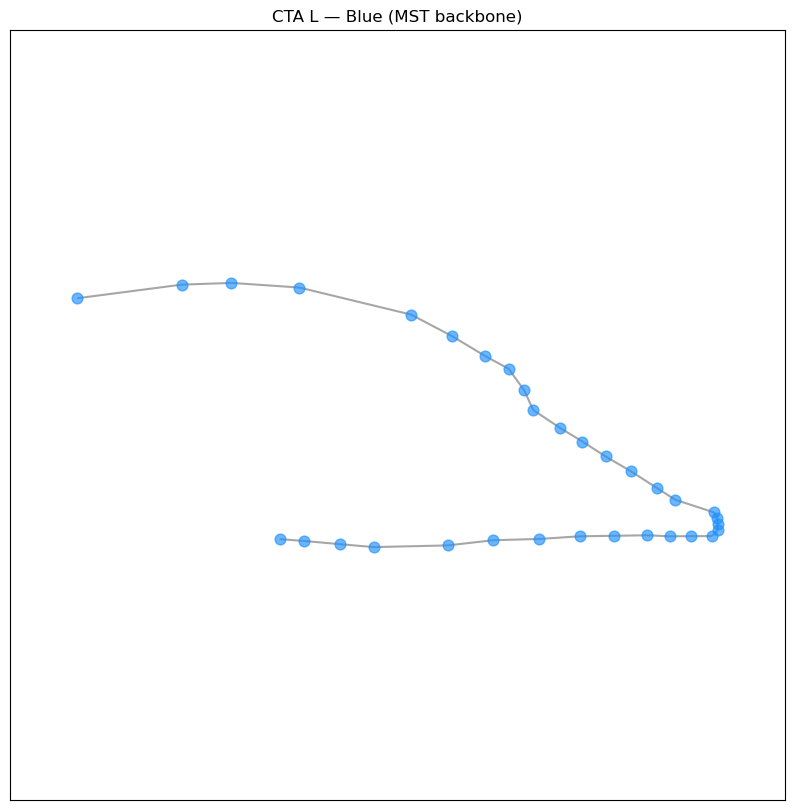

In [9]:
# 1) Cargar CSV
stops = pd.read_csv("CTA_List_of_L_Stops.csv")

# 2) Station-level
stations = prepare_station_level_df(stops)

# 3) Construir una línea (ej: Blue)
G_blue = create_connected_graph_from_cta(stations, "Blue")
G_blue_mst = minimum_spanning_tree(G_blue)

# 4) (Opcional) Ajustar conexión manual
# modify_connection(G_blue_mst, remove_edge=(490, 350), add_edge=(490, 380))

# 5) Plot estático
plot_graph(G_blue_mst, "Blue")

# 6) GeoDataFrames para mapa interactivo
blue_nodes_gdf, blue_edges_gdf = graph_to_geodataframes(G_blue_mst)


In [10]:
graphs = {}
msts = {}
layers = {}

for line_name in LINE_COLS.keys():
    G = create_connected_graph_from_cta(stations, line_name)
    T = minimum_spanning_tree(G)
    graphs[line_name] = G
    msts[line_name] = T
    layers[line_name] = graph_to_geodataframes(T)  # (nodes_gdf, edges_gdf)

In [11]:
import pandas as pd
import numpy as np
import re
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString

from lonboard import Map, ScatterplotLayer, PathLayer
import ipywidgets as widgets
from IPython.display import display


# ----------------------------
# Config líneas (CTA)
# ----------------------------
LINE_COLS = {
    "Red": "RED",
    "Blue": "BLUE",
    "Green": "G",
    "Brown": "BRN",
    "Purple": "P",
    "Yellow": "Y",
    "Pink": "Pnk",
    "Orange": "O",
}

RGBA = {
    "Red":    [220,  30,  38, 180],
    "Blue":   [  0, 122, 255, 180],
    "Green":  [ 52, 199,  89, 180],
    "Brown":  [150,  75,   0, 180],
    "Purple": [175,  82, 222, 180],
    "Yellow": [255, 204,   0, 180],
    "Pink":   [255,  45,  85, 180],
    "Orange": [255, 149,   0, 180],
}

POSITRON = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"


# ----------------------------
# Utils: parse + station-level
# ----------------------------
def _parse_location_to_latlon(val):
    m = re.search(r"\(\s*([-\d\.]+)\s*,\s*([-\d\.]+)\s*\)", str(val))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))  # (lat, lon)

def prepare_station_level_df(stops_df: pd.DataFrame) -> pd.DataFrame:
    df = stops_df.copy()

    latlon = df["Location"].apply(_parse_location_to_latlon)
    df["LATITUDE"] = latlon.apply(lambda x: x[0])
    df["LONGITUDE"] = latlon.apply(lambda x: x[1])

    # normalizar bools
    for col in LINE_COLS.values():
        if df[col].dtype == object:
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": True, "false": False})
            )
        df[col] = df[col].fillna(False).astype(bool)

    # colapsar por estación (MAP_ID)
    agg = {
        "STATION_NAME": "first",
        "STATION_DESCRIPTIVE_NAME": "first",
        "LATITUDE": "first",
        "LONGITUDE": "first",
    }
    for col in LINE_COLS.values():
        agg[col] = "max"

    stations = (
        df.groupby("MAP_ID", as_index=False)
          .agg(agg)
          .dropna(subset=["LATITUDE", "LONGITUDE"])
    )
    stations["MAP_ID"] = stations["MAP_ID"].astype(int)
    return stations


# ----------------------------
# Distancia geodésica (metros)
# ----------------------------
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1 = np.radians(lat1); phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2.0)**2
    return float(2.0 * R * np.arcsin(np.sqrt(a)))


# ----------------------------
# Grafo por línea -> MST
# ----------------------------
def build_line_mst_graph(stations_df: pd.DataFrame, line_name: str) -> nx.Graph:
    line_col = LINE_COLS[line_name]
    sub = stations_df[stations_df[line_col]].copy()

    G = nx.Graph(line=line_name)

    for _, r in sub.iterrows():
        nid = int(r["MAP_ID"])
        lon = float(r["LONGITUDE"])
        lat = float(r["LATITUDE"])
        G.add_node(
            nid,
            pos=(lon, lat),
            station_name=r["STATION_NAME"],
            station_desc=r["STATION_DESCRIPTIVE_NAME"],
        )

    # Grafo completo (por línea es pequeño) -> MST
    nodes = list(G.nodes(data=True))
    for i in range(len(nodes)):
        u, du = nodes[i]
        lon1, lat1 = du["pos"]
        for j in range(i + 1, len(nodes)):
            v, dv = nodes[j]
            lon2, lat2 = dv["pos"]
            G.add_edge(u, v, weight=haversine_m(lon1, lat1, lon2, lat2))

    T = nx.minimum_spanning_tree(G, weight="weight")
    T.graph["line"] = line_name
    return T


# ----------------------------
# G -> GeoDataFrames -> lonboard layers (CORRECTO)
# ----------------------------
def graph_to_lonboard_layers(T: nx.Graph, rgba):
    pos = nx.get_node_attributes(T, "pos")

    # Nodes GDF (tooltip: Station, Line, MAP_ID)
    node_rows = []
    for n, data in T.nodes(data=True):
        lon, lat = pos[n]
        node_rows.append({
            "MAP_ID": n,
            "Line": T.graph.get("line"),
            "Station": data.get("station_name"),
            "Desc": data.get("station_desc"),
            "geometry": Point(lon, lat),
        })
    nodes_gdf = gpd.GeoDataFrame(node_rows, crs="EPSG:4326")

    # Edges GDF (LineString)
    edge_rows = []
    for u, v, data in T.edges(data=True):
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        edge_rows.append({
            "Line": T.graph.get("line"),
            "u": u, "v": v,
            "weight_m": float(data.get("weight", 0.0)),
            "geometry": LineString([(lon1, lat1), (lon2, lat2)]),
        })
    edges_gdf = gpd.GeoDataFrame(edge_rows, crs="EPSG:4326")

    # Capas lonboard (desde geopandas)
    stations_layer = ScatterplotLayer.from_geopandas(
        nodes_gdf[["MAP_ID","Line","Station","Desc","geometry"]],  # controla tooltip
        get_fill_color=rgba,
        get_line_color=[0, 0, 0, 40],
        get_line_width=1,
        radius_units="pixels",
        get_radius=5,
        radius_min_pixels=2,
        radius_max_pixels=10,
        opacity=0.85,
        pickable=True,
        auto_highlight=True,
    )

    edges_layer = PathLayer.from_geopandas(
        edges_gdf[["Line","u","v","weight_m","geometry"]],
        get_color=rgba,
        width_units="pixels",
        get_width=2,
        width_min_pixels=1,
        width_max_pixels=6,
        opacity=0.70,
        pickable=False,
    )

    return stations_layer, edges_layer


# ----------------------------
# Construir TODAS las líneas + UI toggles
# ----------------------------
stops = pd.read_csv("CTA_List_of_L_Stops.csv")
stations = prepare_station_level_df(stops)

cta_layers = {}       # line -> {"stations": layer, "edges": layer}
all_layers_list = []  # para Map

for line_name in LINE_COLS.keys():
    T = build_line_mst_graph(stations, line_name)
    st_layer, ed_layer = graph_to_lonboard_layers(T, RGBA[line_name])

    cta_layers[line_name] = {"stations": st_layer, "edges": ed_layer}
    all_layers_list.append(ed_layer)   # edges primero
    all_layers_list.append(st_layer)   # stations encima


# --- Si quieres sumar tus capas (work_layer, home_layer), descomenta:
# all_layers_list += [work_layer, home_layer]


m = Map(
    all_layers_list,
    basemap_style=POSITRON,
    height=820,
    show_tooltip=True,
    show_side_panel=False,
    picking_radius=6,
    view_state={"longitude": -87.6298, "latitude": 41.8781, "zoom": 10.6},
)


# ----------------------------
# Checkboxes por línea
# ----------------------------
chk_all = widgets.Checkbox(value=True, description="CTA Lines (All)")
chk_edges = widgets.Checkbox(value=True, description="Edges")
chk_stations = widgets.Checkbox(value=True, description="Stations")

line_checks = {ln: widgets.Checkbox(value=True, description=ln) for ln in LINE_COLS.keys()}

def _apply_visibility():
    for ln, chk in line_checks.items():
        cta_layers[ln]["edges"].visible = chk.value and chk_edges.value
        cta_layers[ln]["stations"].visible = chk.value and chk_stations.value

def toggle_all(_=None):
    v = chk_all.value
    for ln in line_checks:
        line_checks[ln].value = v
    _apply_visibility()

def toggle_one(_=None):
    _apply_visibility()
    chk_all.value = all(chk.value for chk in line_checks.values())

chk_all.observe(toggle_all, names="value")
chk_edges.observe(toggle_one, names="value")
chk_stations.observe(toggle_one, names="value")







for chk in line_checks.values():
    chk.observe(toggle_one, names="value")

ui = widgets.VBox([
    widgets.HBox([chk_all, chk_edges, chk_stations]),
    widgets.HBox([
        widgets.VBox(list(line_checks.values())[:4]),
        widgets.VBox(list(line_checks.values())[4:]),
    ])
])

display(ui)
m


C:\Users\danhm\AppData\Local\Temp\ipykernel_18948\1471440408.py:215: DeprecationWarning: `basemap_style` is deprecated and will be removed in 0.14. Use `basemap` instead.
  m = Map(


In [12]:
import pandas as pd
import numpy as np
import re
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString

from lonboard import Map, ScatterplotLayer, PathLayer
import ipywidgets as widgets
from IPython.display import display


# ----------------------------
# Config líneas (CTA)
# ----------------------------
LINE_COLS = {
    "Red": "RED",
    "Blue": "BLUE",
    "Green": "G",
    "Brown": "BRN",
    "Purple": "P",
    "Yellow": "Y",
    "Pink": "Pnk",
    "Orange": "O",
}

RGBA = {
    "Red":    [220,  30,  38, 180],
    "Blue":   [  0, 122, 255, 180],
    "Green":  [ 52, 199,  89, 180],
    "Brown":  [150,  75,   0, 180],
    "Purple": [175,  82, 222, 180],
    "Yellow": [255, 204,   0, 180],
    "Pink":   [255,  45,  85, 180],
    "Orange": [255, 149,   0, 180],
}

POSITRON = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"


# ----------------------------
# Utils: parse + station-level
# ----------------------------
def _parse_location_to_latlon(val):
    m = re.search(r"\(\s*([-\d\.]+)\s*,\s*([-\d\.]+)\s*\)", str(val))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))  # (lat, lon)

def prepare_station_level_df(stops_df: pd.DataFrame) -> pd.DataFrame:
    df = stops_df.copy()

    latlon = df["Location"].apply(_parse_location_to_latlon)
    df["LATITUDE"] = latlon.apply(lambda x: x[0])
    df["LONGITUDE"] = latlon.apply(lambda x: x[1])

    # normalizar bools
    for col in LINE_COLS.values():
        if df[col].dtype == object:
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": True, "false": False})
            )
        df[col] = df[col].fillna(False).astype(bool)

    # colapsar por estación (MAP_ID)
    agg = {
        "STATION_NAME": "first",
        "STATION_DESCRIPTIVE_NAME": "first",
        "LATITUDE": "first",
        "LONGITUDE": "first",
    }
    for col in LINE_COLS.values():
        agg[col] = "max"

    stations = (
        df.groupby("MAP_ID", as_index=False)
          .agg(agg)
          .dropna(subset=["LATITUDE", "LONGITUDE"])
    )
    stations["MAP_ID"] = stations["MAP_ID"].astype(int)
    return stations


# ----------------------------
# Distancia geodésica (metros)
# ----------------------------
def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1 = np.radians(lat1); phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2.0)**2
    return float(2.0 * R * np.arcsin(np.sqrt(a)))


# ----------------------------
# Grafo por línea -> MST
# ----------------------------
def build_line_mst_graph(stations_df: pd.DataFrame, line_name: str) -> nx.Graph:
    line_col = LINE_COLS[line_name]
    sub = stations_df[stations_df[line_col]].copy()

    G = nx.Graph(line=line_name)

    for _, r in sub.iterrows():
        nid = int(r["MAP_ID"])
        lon = float(r["LONGITUDE"])
        lat = float(r["LATITUDE"])
        G.add_node(
            nid,
            pos=(lon, lat),
            station_name=r["STATION_NAME"],
            station_desc=r["STATION_DESCRIPTIVE_NAME"],
        )

    # Grafo completo (por línea es pequeño) -> MST
    nodes = list(G.nodes(data=True))
    for i in range(len(nodes)):
        u, du = nodes[i]
        lon1, lat1 = du["pos"]
        for j in range(i + 1, len(nodes)):
            v, dv = nodes[j]
            lon2, lat2 = dv["pos"]
            G.add_edge(u, v, weight=haversine_m(lon1, lat1, lon2, lat2))

    T = nx.minimum_spanning_tree(G, weight="weight")
    T.graph["line"] = line_name
    return T


# ----------------------------
# Agregar conexiones manuales (LOOP)
# ----------------------------
def add_manual_edges(G: nx.Graph, edges: list[tuple[int, int]]):
    """
    Agrega aristas manuales al grafo usando pos=(lon,lat) para calcular weight.
    """
    pos = nx.get_node_attributes(G, "pos")
    for u, v in edges:
        u, v = int(u), int(v)
        if u not in pos or v not in pos:
            print(f"[{G.graph.get('line')}] No existe u/v en el grafo: ({u}, {v}) -> skip")
            continue
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        w = haversine_m(lon1, lat1, lon2, lat2)
        G.add_edge(u, v, weight=float(w))


# ----------------------------
# G -> GeoDataFrames -> lonboard layers
# ----------------------------
def graph_to_lonboard_layers(T: nx.Graph, rgba):
    pos = nx.get_node_attributes(T, "pos")

    # Nodes GDF (tooltip: Station, Line, MAP_ID)
    node_rows = []
    for n, data in T.nodes(data=True):
        lon, lat = pos[n]
        node_rows.append({
            "MAP_ID": n,
            "Line": T.graph.get("line"),
            "Station": data.get("station_name"),
            "Desc": data.get("station_desc"),
            "geometry": Point(lon, lat),
        })
    nodes_gdf = gpd.GeoDataFrame(node_rows, crs="EPSG:4326")

    # Edges GDF (LineString)
    edge_rows = []
    for u, v, data in T.edges(data=True):
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        edge_rows.append({
            "Line": T.graph.get("line"),
            "u": u, "v": v,
            "weight_m": float(data.get("weight", 0.0)),
            "geometry": LineString([(lon1, lat1), (lon2, lat2)]),
        })
    edges_gdf = gpd.GeoDataFrame(edge_rows, crs="EPSG:4326")

    stations_layer = ScatterplotLayer.from_geopandas(
        nodes_gdf[["MAP_ID","Line","Station","Desc","geometry"]],
        get_fill_color=rgba,
        get_line_color=[0, 0, 0, 40],
        get_line_width=1,
        radius_units="pixels",
        get_radius=5,
        radius_min_pixels=2,
        radius_max_pixels=10,
        opacity=0.85,
        pickable=True,
        auto_highlight=True,
    )

    edges_layer = PathLayer.from_geopandas(
        edges_gdf[["Line","u","v","weight_m","geometry"]],
        get_color=rgba,
        width_units="pixels",
        get_width=2,
        width_min_pixels=1,
        width_max_pixels=6,
        opacity=0.70,
        pickable=False,
    )

    return stations_layer, edges_layer


# ----------------------------
# Construir TODAS las líneas + (LOOP) + UI toggles
# ----------------------------
stops = pd.read_csv("CTA_List_of_L_Stops.csv")
stations = prepare_station_level_df(stops)

# Guarda grafos por línea para que puedas editar después
cta_graphs = {}

cta_layers = {}       # line -> {"stations": layer, "edges": layer}
all_layers_list = []  # para Map

# Conexión especial del loop
LOOP_EDGE = (40730, 40040)
LOOP_LINES = {"Orange", "Pink", "Purple", "Brown"}

for line_name in LINE_COLS.keys():
    T = build_line_mst_graph(stations, line_name)

    # Agrega la conexión especial SOLO a líneas del loop
    if line_name in LOOP_LINES:
        add_manual_edges(T, [LOOP_EDGE])

    # guarda el grafo
    cta_graphs[line_name] = T

    # capas
    st_layer, ed_layer = graph_to_lonboard_layers(T, RGBA[line_name])
    cta_layers[line_name] = {"stations": st_layer, "edges": ed_layer}
    all_layers_list.append(ed_layer)
    all_layers_list.append(st_layer)

# --- Si quieres sumar tus capas (work_layer, home_layer), descomenta:
# all_layers_list += [work_layer, home_layer]

m = Map(
    all_layers_list,
    basemap_style=POSITRON,
    height=820,
    show_tooltip=True,
    show_side_panel=False,
    picking_radius=6,
    view_state={"longitude": -87.6298, "latitude": 41.8781, "zoom": 10.6},
)


# ----------------------------
# Checkboxes por línea
# ----------------------------
chk_all = widgets.Checkbox(value=True, description="CTA Lines (All)")
chk_edges = widgets.Checkbox(value=True, description="Edges")
chk_stations = widgets.Checkbox(value=True, description="Stations")

line_checks = {ln: widgets.Checkbox(value=True, description=ln) for ln in LINE_COLS.keys()}

def _apply_visibility():
    for ln, chk in line_checks.items():
        cta_layers[ln]["edges"].visible = chk.value and chk_edges.value
        cta_layers[ln]["stations"].visible = chk.value and chk_stations.value

def toggle_all(_=None):
    v = chk_all.value
    for ln in line_checks:
        line_checks[ln].value = v
    _apply_visibility()

def toggle_one(_=None):
    _apply_visibility()
    chk_all.value = all(chk.value for chk in line_checks.values())

chk_all.observe(toggle_all, names="value")
chk_edges.observe(toggle_one, names="value")
chk_stations.observe(toggle_one, names="value")

for chk in line_checks.values():
    chk.observe(toggle_one, names="value")

ui = widgets.VBox([
    widgets.HBox([chk_all, chk_edges, chk_stations]),
    widgets.HBox([
        widgets.VBox(list(line_checks.values())[:4]),
        widgets.VBox(list(line_checks.values())[4:]),
    ])
])

display(ui)
m


C:\Users\danhm\AppData\Local\Temp\ipykernel_18948\3839782577.py:246: DeprecationWarning: `basemap_style` is deprecated and will be removed in 0.14. Use `basemap` instead.
  m = Map(


In [13]:
# =========================
# FLOW MAP (CTA) — 1 cell
# AM: 1am–11am  |  PM: 1pm–11pm
# Asume: TODOS usan CTA
# Inputs esperados en memoria:
#   - Origin_Destination_Jobs_Chicago (cols: h_lat,h_lon,w_lat,w_lon y opcional S000)
#   - archivo: CTA_List_of_L_Stops.csv (con MAP_ID, Location, flags de líneas)
# =========================

import pandas as pd
import numpy as np
import re
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString

from lonboard import Map, ScatterplotLayer, PathLayer
import ipywidgets as widgets
from IPython.display import display


# ----------------------------
# CONFIG
# ----------------------------
LINE_COLS = {
    "Red": "RED",
    "Blue": "BLUE",
    "Green": "G",
    "Brown": "BRN",
    "Purple": "P",
    "Yellow": "Y",
    "Pink": "Pnk",
    "Orange": "O",
}

RGBA = {
    "Red":    [220,  30,  38, 180],
    "Blue":   [  0, 122, 255, 180],
    "Green":  [ 52, 199,  89, 180],
    "Brown":  [150,  75,   0, 180],
    "Purple": [175,  82, 222, 180],
    "Yellow": [255, 204,   0, 180],
    "Pink":   [255,  45,  85, 180],
    "Orange": [255, 149,   0, 180],
}

POSITRON = "https://basemaps.cartocdn.com/gl/positron-gl-style/style.json"

# Probabilidad de asignación a estaciones (suavidad)
K_NEIGHBORS = 3
SCALE_ASSIGN_M = 800.0  # baja => más determinista (estación más cercana). sube => reparte más

# Render / performance
TOP_EDGES = 400  # edges más cargados a mostrar
FLOW_ALPHA = 200
FLOW_RGBA_AM = [0, 122, 255, FLOW_ALPHA]
FLOW_RGBA_PM = [255, 149, 0, FLOW_ALPHA]

# Conexión especial para cerrar el loop en tus líneas (si no existen, se ignoran)
LOOP_EDGE = (40730, 40040)
LOOP_LINES = {"Orange", "Pink", "Purple", "Brown"}


# ----------------------------
# UTILS
# ----------------------------
def _parse_location_to_latlon(val):
    m = re.search(r"\(\s*([-\d\.]+)\s*,\s*([-\d\.]+)\s*\)", str(val))
    if not m:
        return (np.nan, np.nan)
    return (float(m.group(1)), float(m.group(2)))  # (lat, lon)

def prepare_station_level_df(stops_df: pd.DataFrame) -> pd.DataFrame:
    df = stops_df.copy()
    latlon = df["Location"].apply(_parse_location_to_latlon)
    df["LATITUDE"] = latlon.apply(lambda x: x[0])
    df["LONGITUDE"] = latlon.apply(lambda x: x[1])

    for col in LINE_COLS.values():
        if df[col].dtype == object:
            df[col] = (
                df[col].astype(str).str.strip().str.lower()
                .map({"true": True, "false": False})
            )
        df[col] = df[col].fillna(False).astype(bool)

    agg = {
        "STATION_NAME": "first",
        "STATION_DESCRIPTIVE_NAME": "first",
        "LATITUDE": "first",
        "LONGITUDE": "first",
    }
    for col in LINE_COLS.values():
        agg[col] = "max"

    stations = (
        df.groupby("MAP_ID", as_index=False)
          .agg(agg)
          .dropna(subset=["LATITUDE", "LONGITUDE"])
    )
    stations["MAP_ID"] = stations["MAP_ID"].astype(int)
    return stations

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    phi1 = np.radians(lat1); phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2.0)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlmb/2.0)**2
    return float(2.0 * R * np.arcsin(np.sqrt(a)))

def knn_stations(points_latlon, stations_latlon, k=3):
    """
    points_latlon: (N,2) lat,lon
    stations_latlon: (M,2) lat,lon
    returns: idx (N,k), dist_m (N,k)
    """
    points_latlon = np.asarray(points_latlon, dtype=float)
    stations_latlon = np.asarray(stations_latlon, dtype=float)

    # BallTree (haversine) si está sklearn
    try:
        from sklearn.neighbors import BallTree
        pts_rad = np.radians(points_latlon[:, [0, 1]])   # lat,lon
        sts_rad = np.radians(stations_latlon[:, [0, 1]]) # lat,lon
        tree = BallTree(sts_rad, metric="haversine")
        dist_rad, idx = tree.query(pts_rad, k=min(k, len(stations_latlon)))
        dist_m = dist_rad * 6371000.0
        return idx, dist_m
    except Exception:
        # fallback cKDTree (EPSG:3857)
        from scipy.spatial import cKDTree
        g_st = gpd.GeoSeries(
            gpd.points_from_xy(stations_latlon[:, 1], stations_latlon[:, 0]),
            crs="EPSG:4326"
        ).to_crs("EPSG:3857")
        st_xy = np.c_[g_st.x.to_numpy(), g_st.y.to_numpy()]
        tree = cKDTree(st_xy)

        g_pt = gpd.GeoSeries(
            gpd.points_from_xy(points_latlon[:, 1], points_latlon[:, 0]),
            crs="EPSG:4326"
        ).to_crs("EPSG:3857")
        pt_xy = np.c_[g_pt.x.to_numpy(), g_pt.y.to_numpy()]

        dist_m, idx = tree.query(pt_xy, k=min(k, len(st_xy)))
        if dist_m.ndim == 1:
            dist_m = dist_m[:, None]
            idx = idx[:, None]
        return idx, dist_m

def softmax_neg_dist(dist_m, scale_m):
    x = -dist_m / max(scale_m, 1e-6)
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)


# ----------------------------
# CTA NETWORK (MST por línea) + unión en un solo grafo de red
# ----------------------------
def build_line_mst_graph(stations_df: pd.DataFrame, line_name: str) -> nx.Graph:
    line_col = LINE_COLS[line_name]
    sub = stations_df[stations_df[line_col]].copy()

    G = nx.Graph(line=line_name)

    for _, r in sub.iterrows():
        nid = int(r["MAP_ID"])
        lon = float(r["LONGITUDE"])
        lat = float(r["LATITUDE"])
        G.add_node(
            nid,
            pos=(lon, lat),
            station_name=r["STATION_NAME"],
            station_desc=r["STATION_DESCRIPTIVE_NAME"],
        )

    nodes = list(G.nodes(data=True))
    for i in range(len(nodes)):
        u, du = nodes[i]
        lon1, lat1 = du["pos"]
        for j in range(i + 1, len(nodes)):
            v, dv = nodes[j]
            lon2, lat2 = dv["pos"]
            G.add_edge(u, v, weight=haversine_m(lon1, lat1, lon2, lat2))

    T = nx.minimum_spanning_tree(G, weight="weight")
    T.graph["line"] = line_name
    return T

def add_manual_edges(G: nx.Graph, edges):
    pos = nx.get_node_attributes(G, "pos")
    for u, v in edges:
        u, v = int(u), int(v)
        if u not in pos or v not in pos:
            continue
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        w = haversine_m(lon1, lat1, lon2, lat2)
        G.add_edge(u, v, weight=float(w))

def graph_to_lonboard_layers(T: nx.Graph, rgba):
    pos = nx.get_node_attributes(T, "pos")

    node_rows = []
    for n, data in T.nodes(data=True):
        lon, lat = pos[n]
        node_rows.append({
            "MAP_ID": n,
            "Line": T.graph.get("line"),
            "Station": data.get("station_name"),
            "Desc": data.get("station_desc"),
            "geometry": Point(lon, lat),
        })
    nodes_gdf = gpd.GeoDataFrame(node_rows, crs="EPSG:4326")

    edge_rows = []
    for u, v, data in T.edges(data=True):
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        edge_rows.append({
            "Line": T.graph.get("line"),
            "u": u, "v": v,
            "weight_m": float(data.get("weight", 0.0)),
            "geometry": LineString([(lon1, lat1), (lon2, lat2)]),
        })
    edges_gdf = gpd.GeoDataFrame(edge_rows, crs="EPSG:4326")

    stations_layer = ScatterplotLayer.from_geopandas(
        nodes_gdf[["MAP_ID","Line","Station","Desc","geometry"]],
        get_fill_color=rgba,
        get_line_color=[0, 0, 0, 35],
        get_line_width=1,
        radius_units="pixels",
        get_radius=4,
        radius_min_pixels=2,
        radius_max_pixels=9,
        opacity=0.60,
        pickable=True,
        auto_highlight=True,
    )

    edges_layer = PathLayer.from_geopandas(
        edges_gdf[["Line","u","v","weight_m","geometry"]],
        get_color=rgba,
        width_units="pixels",
        get_width=2,
        width_min_pixels=1,
        width_max_pixels=5,
        opacity=0.40,
        pickable=False,
    )

    return stations_layer, edges_layer

def union_network_from_lines(cta_graphs):
    """
    Une todos los grafos de línea en un solo grafo (red completa).
    """
    G = nx.Graph()
    for ln, T in cta_graphs.items():
        # nodos
        for n, data in T.nodes(data=True):
            if n not in G:
                G.add_node(n, **data)
        # aristas
        for u, v, data in T.edges(data=True):
            w = float(data.get("weight", 1.0))
            if G.has_edge(u, v):
                # conservar la más corta
                if w < G[u][v].get("weight", w):
                    G[u][v]["weight"] = w
            else:
                G.add_edge(u, v, weight=w)
    return G


# ----------------------------
# MODELO: TODOS usan CTA
# Asignación home->estación y work->estación por cercanía (soft)
# ----------------------------
def compute_station_flow_matrix_all_use_cta(
    od_df: pd.DataFrame,
    stations_df: pd.DataFrame,
    *,
    k=3,
    scale_assign_m=800.0,
    weight_col=None,
):
    df = od_df.copy()

    # peso
    if weight_col is None:
        weight_col = "S000" if "S000" in df.columns else None
    if weight_col is None:
        df["_w"] = 1.0
        weight_col = "_w"

    df = df.dropna(subset=["h_lat","h_lon","w_lat","w_lon", weight_col]).copy()
    df[weight_col] = df[weight_col].astype(float)

    # agrupar (reduce tamaño)
    df = df.groupby(["h_lat","h_lon","w_lat","w_lon"], as_index=False)[weight_col].sum()

    station_ids = stations_df["MAP_ID"].to_numpy(dtype=int)
    st_latlon = stations_df[["LATITUDE","LONGITUDE"]].to_numpy(dtype=float)
    nS = len(station_ids)

    # id->idx
    max_id = int(station_ids.max())
    id_to_idx = np.full(max_id + 1, -1, dtype=int)
    id_to_idx[station_ids] = np.arange(nS, dtype=int)

    homes = df[["h_lat","h_lon"]].drop_duplicates().reset_index(drop=True)
    works = df[["w_lat","w_lon"]].drop_duplicates().reset_index(drop=True)

    h_idx, h_dist = knn_stations(homes[["h_lat","h_lon"]].to_numpy(), st_latlon, k=k)
    w_idx, w_dist = knn_stations(works[["w_lat","w_lon"]].to_numpy(), st_latlon, k=k)

    p_h = softmax_neg_dist(h_dist, scale_assign_m)
    p_w = softmax_neg_dist(w_dist, scale_assign_m)

    df = df.merge(homes.assign(_hid=np.arange(len(homes))), on=["h_lat","h_lon"], how="left")
    df = df.merge(works.assign(_wid=np.arange(len(works))), on=["w_lat","w_lon"], how="left")

    hid = df["_hid"].to_numpy(dtype=int)
    wid = df["_wid"].to_numpy(dtype=int)
    wgt = df[weight_col].to_numpy(dtype=float)

    flow = np.zeros((nS, nS), dtype=np.float32)

    CHUNK = 50000
    for start in range(0, len(df), CHUNK):
        end = min(start + CHUNK, len(df))

        hid_c = hid[start:end]
        wid_c = wid[start:end]
        wgt_c = wgt[start:end]

        st_h = station_ids[h_idx[hid_c]]   # (c,k) MAP_ID
        st_w = station_ids[w_idx[wid_c]]   # (c,k) MAP_ID

        ph = p_h[hid_c]                    # (c,k)
        pw = p_w[wid_c]                    # (c,k)

        # TODOS USAN CTA (no factor extra)
        val = (wgt_c)[:, None, None] * (ph[:, :, None] * pw[:, None, :])  # (c,k,k)

        u_flat = st_h[:, :, None].reshape(-1)
        v_flat = st_w[:, None, :].reshape(-1)
        val_flat = val.reshape(-1).astype(np.float32)

        ok = (u_flat <= max_id) & (v_flat <= max_id)
        u_m = id_to_idx[u_flat[ok]]
        v_m = id_to_idx[v_flat[ok]]
        vv = val_flat[ok]

        ok2 = (u_m >= 0) & (v_m >= 0)
        np.add.at(flow, (u_m[ok2], v_m[ok2]), vv[ok2])

    return flow, station_ids


# ----------------------------
# FLOW: repartir OD por tiempo (1..11) AM y PM
# ----------------------------
AM_PROFILE = np.array([0.003, 0.003, 0.004, 0.008, 0.020, 0.080, 0.190, 0.230, 0.190, 0.140, 0.090], dtype=float)
AM_PROFILE = AM_PROFILE / AM_PROFILE.sum()

PM_PROFILE = np.array([0.010, 0.015, 0.030, 0.080, 0.160, 0.200, 0.180, 0.140, 0.090, 0.060, 0.035], dtype=float)
PM_PROFILE = PM_PROFILE / PM_PROFILE.sum()

def build_edge_loads_from_station_flows(flow_matrix, station_ids, G_net):
    """
    Convierte OD estación->estación en cargas por arista de la red (sumando sobre caminos más cortos).
    """
    # paths precomputados (muy rápido con ~150 nodos)
    paths = dict(nx.all_pairs_dijkstra_path(G_net, weight="weight"))

    nS = len(station_ids)
    edge_load = {}  # (min(u,v), max(u,v)) -> float

    for i in range(nS):
        u = int(station_ids[i])
        if u not in paths:
            continue
        row = flow_matrix[i]
        for j in range(nS):
            f = float(row[j])
            if f <= 0:
                continue
            v = int(station_ids[j])
            if v == u:
                continue
            try:
                path = paths[u][v]
            except KeyError:
                continue

            for a, b in zip(path[:-1], path[1:]):
                e = (a, b) if a < b else (b, a)
                edge_load[e] = edge_load.get(e, 0.0) + f

    return edge_load

def edges_gdf_for_hour(edge_load, G_net, hour_in_window, period="AM", top_edges=400):
    share = AM_PROFILE[hour_in_window - 1] if period == "AM" else PM_PROFILE[hour_in_window - 1]

    pos = nx.get_node_attributes(G_net, "pos")
    rows = []
    for u, v, data in G_net.edges(data=True):
        a, b = (u, v) if u < v else (v, u)
        f = edge_load.get((a, b), 0.0) * share
        if f <= 0:
            continue
        lon1, lat1 = pos[u]
        lon2, lat2 = pos[v]
        rows.append({
            "Flow": float(f),
            "u": int(u),
            "v": int(v),
            "geometry": LineString([(lon1, lat1), (lon2, lat2)]),
        })

    gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
    if len(gdf) == 0:
        return gpd.GeoDataFrame({"Flow": [], "width": [], "u": [], "v": [], "geometry": []}, crs="EPSG:4326")

    # top edges
    gdf = gdf.sort_values("Flow", ascending=False).head(top_edges).copy()

    # width robusto
    q95 = float(gdf["Flow"].quantile(0.95)) if len(gdf) else 1.0
    q95 = q95 if q95 > 0 else 1.0
    gdf["width"] = (1.0 + 10.0 * np.sqrt(np.minimum(gdf["Flow"], q95) / q95)).astype(np.float32)

    return gdf

def nodes_gdf_for_hour(flow_matrix, stations_df, station_ids, hour_in_window, period="AM"):
    share = AM_PROFILE[hour_in_window - 1] if period == "AM" else PM_PROFILE[hour_in_window - 1]
    M = flow_matrix if period == "AM" else flow_matrix.T
    M_h = (M * share).astype(np.float32)

    outflow = M_h.sum(axis=1)
    inflow  = M_h.sum(axis=0)
    total = outflow + inflow

    st = stations_df.set_index("MAP_ID").loc[station_ids]
    gdf = gpd.GeoDataFrame({
        "MAP_ID": station_ids,
        "Out": outflow.astype(np.float32),
        "In": inflow.astype(np.float32),
        "Total": total.astype(np.float32),
        "geometry": gpd.points_from_xy(st["LONGITUDE"], st["LATITUDE"]),
    }, crs="EPSG:4326")

    q95 = float(np.quantile(gdf["Total"], 0.95)) if len(gdf) else 1.0
    q95 = q95 if q95 > 0 else 1.0
    gdf["radius"] = (2.0 + 10.0 * np.sqrt(np.minimum(gdf["Total"], q95) / q95)).astype(np.float32)
    return gdf


# ============================================================
# RUN
# ============================================================

# --- requiere tu DF OD en memoria ---
if "Origin_Destination_Jobs_Chicago" not in globals():
    raise NameError("No encuentro 'Origin_Destination_Jobs_Chicago' en memoria. Cárgalo antes de correr esta celda.")

# 1) estaciones CTA
stops = pd.read_csv("CTA_List_of_L_Stops.csv")
stations = prepare_station_level_df(stops)

# 2) construir todas las líneas (MST) + loop edge (si aplica) + layers
cta_graphs = {}
cta_layers = {}
base_layers = []

for line_name in LINE_COLS.keys():
    T = build_line_mst_graph(stations, line_name)
    if line_name in LOOP_LINES:
        add_manual_edges(T, [LOOP_EDGE])
    cta_graphs[line_name] = T

    st_layer, ed_layer = graph_to_lonboard_layers(T, RGBA[line_name])
    cta_layers[line_name] = {"stations": st_layer, "edges": ed_layer}
    base_layers += [ed_layer, st_layer]

# 3) grafo de red unificado
G_net = union_network_from_lines(cta_graphs)

# 4) matriz OD estación->estación (TODOS usan CTA)
od = Origin_Destination_Jobs_Chicago.copy()
flow_matrix, station_ids = compute_station_flow_matrix_all_use_cta(
    od,
    stations,
    k=K_NEIGHBORS,
    scale_assign_m=SCALE_ASSIGN_M,
    weight_col=("S000" if "S000" in od.columns else None),
)

# 5) convertir OD a carga por arista de la red (una sola vez)
edge_load = build_edge_loads_from_station_flows(flow_matrix, station_ids, G_net)

# 6) layers de FLOW iniciales
period0 = "AM"
hour0 = 7

edges_gdf0 = edges_gdf_for_hour(edge_load, G_net, hour0, period=period0, top_edges=TOP_EDGES)
nodes_gdf0 = nodes_gdf_for_hour(flow_matrix, stations, station_ids, hour0, period=period0)

flow_edges_layer = PathLayer.from_geopandas(
    edges_gdf0[["Flow","width","u","v","geometry"]],
    get_color=(FLOW_RGBA_AM if period0 == "AM" else FLOW_RGBA_PM),
    width_units="pixels",
    get_width=edges_gdf0["width"].to_numpy(np.float32) if len(edges_gdf0) else 2,
    width_min_pixels=1,
    width_max_pixels=14,
    opacity=0.90,
    pickable=True,
)

flow_nodes_layer = ScatterplotLayer.from_geopandas(
    nodes_gdf0[["MAP_ID","In","Out","Total","radius","geometry"]],
    get_fill_color=[0, 0, 0, 90],
    get_line_color=[0, 0, 0, 40],
    get_line_width=1,
    radius_units="pixels",
    get_radius=nodes_gdf0["radius"].to_numpy(np.float32),
    radius_min_pixels=1,
    radius_max_pixels=14,
    opacity=0.55,
    pickable=True,
    auto_highlight=True,
)

# 7) MAP
m = Map(
    base_layers + [flow_edges_layer, flow_nodes_layer],
    basemap_style=POSITRON,
    height=820,
    show_tooltip=True,
    show_side_panel=False,
    picking_radius=6,
    view_state={"longitude": -87.6298, "latitude": 41.8781, "zoom": 10.6},
)

# ============================================================
# UI
# ============================================================
chk_flow = widgets.Checkbox(value=True, description="Flow")
chk_all = widgets.Checkbox(value=True, description="CTA Lines (All)")
chk_edges = widgets.Checkbox(value=True, description="CTA Edges")
chk_stations = widgets.Checkbox(value=True, description="CTA Stations")

line_checks = {ln: widgets.Checkbox(value=True, description=ln) for ln in LINE_COLS.keys()}

btn_period = widgets.ToggleButtons(options=["AM", "PM"], value="AM", description="Period:")
s_hour = widgets.IntSlider(value=7, min=1, max=11, step=1, description="Hour:", continuous_update=False)
lbl = widgets.HTML()

def _label():
    if btn_period.value == "AM":
        lbl.value = f"<b>Hora:</b> {s_hour.value}:00 AM (casa → trabajo)"
    else:
        lbl.value = f"<b>Hora:</b> {s_hour.value}:00 PM (trabajo → casa)"
_label()

def _apply_visibility():
    # CTA layers
    for ln, chk in line_checks.items():
        cta_layers[ln]["edges"].visible = chk_all.value and chk.value and chk_edges.value
        cta_layers[ln]["stations"].visible = chk_all.value and chk.value and chk_stations.value
    # Flow
    flow_edges_layer.visible = chk_flow.value
    flow_nodes_layer.visible = chk_flow.value

def _rebuild_flow():
    global flow_edges_layer, flow_nodes_layer

    period = btn_period.value
    hour = int(s_hour.value)

    edges_gdf = edges_gdf_for_hour(edge_load, G_net, hour, period=period, top_edges=TOP_EDGES)
    nodes_gdf = nodes_gdf_for_hour(flow_matrix, stations, station_ids, hour, period=period)

    new_edges_layer = PathLayer.from_geopandas(
        edges_gdf[["Flow","width","u","v","geometry"]],
        get_color=(FLOW_RGBA_AM if period == "AM" else FLOW_RGBA_PM),
        width_units="pixels",
        get_width=edges_gdf["width"].to_numpy(np.float32) if len(edges_gdf) else 2,
        width_min_pixels=1,
        width_max_pixels=14,
        opacity=0.90,
        pickable=True,
    )

    new_nodes_layer = ScatterplotLayer.from_geopandas(
        nodes_gdf[["MAP_ID","In","Out","Total","radius","geometry"]],
        get_fill_color=[0, 0, 0, 90],
        get_line_color=[0, 0, 0, 40],
        get_line_width=1,
        radius_units="pixels",
        get_radius=nodes_gdf["radius"].to_numpy(np.float32),
        radius_min_pixels=1,
        radius_max_pixels=14,
        opacity=0.55,
        pickable=True,
        auto_highlight=True,
    )

    new_edges_layer.visible = chk_flow.value
    new_nodes_layer.visible = chk_flow.value

    flow_edges_layer = new_edges_layer
    flow_nodes_layer = new_nodes_layer

    # reconstruye el stack del mapa
    layers_stack = []
    for ln in LINE_COLS.keys():
        layers_stack.append(cta_layers[ln]["edges"])
        layers_stack.append(cta_layers[ln]["stations"])
    layers_stack += [flow_edges_layer, flow_nodes_layer]
    m.layers = layers_stack

    _apply_visibility()
    _label()

def _toggle_all_lines(_=None):
    v = chk_all.value
    for ln in line_checks:
        line_checks[ln].value = v
    _apply_visibility()

def _toggle_any(_=None):
    _apply_visibility()
    chk_all.value = all(chk.value for chk in line_checks.values())

# observe
chk_flow.observe(lambda _: _apply_visibility(), names="value")
chk_edges.observe(lambda _: _apply_visibility(), names="value")
chk_stations.observe(lambda _: _apply_visibility(), names="value")

chk_all.observe(_toggle_all_lines, names="value")
for chk in line_checks.values():
    chk.observe(_toggle_any, names="value")

btn_period.observe(lambda _: _rebuild_flow(), names="value")
s_hour.observe(lambda _: _rebuild_flow(), names="value")

ui = widgets.VBox([
    widgets.HBox([chk_flow, chk_all, chk_edges, chk_stations]),
    widgets.HBox([btn_period, s_hour]),
    widgets.HBox([
        widgets.VBox(list(line_checks.values())[:4]),
        widgets.VBox(list(line_checks.values())[4:]),
    ]),
    lbl
])

display(ui)
_apply_visibility()
m


NameError: No encuentro 'Origin_Destination_Jobs_Chicago' en memoria. Cárgalo antes de correr esta celda.